In [2]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

/tmp/ipykernel_282843/3932157345.py:16: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.barplot(
/tmp/ipykernel_282843/3932157345.py:16: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.barplot(
/tmp/ipykernel_282843/3932157345.py:16: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.barplot(


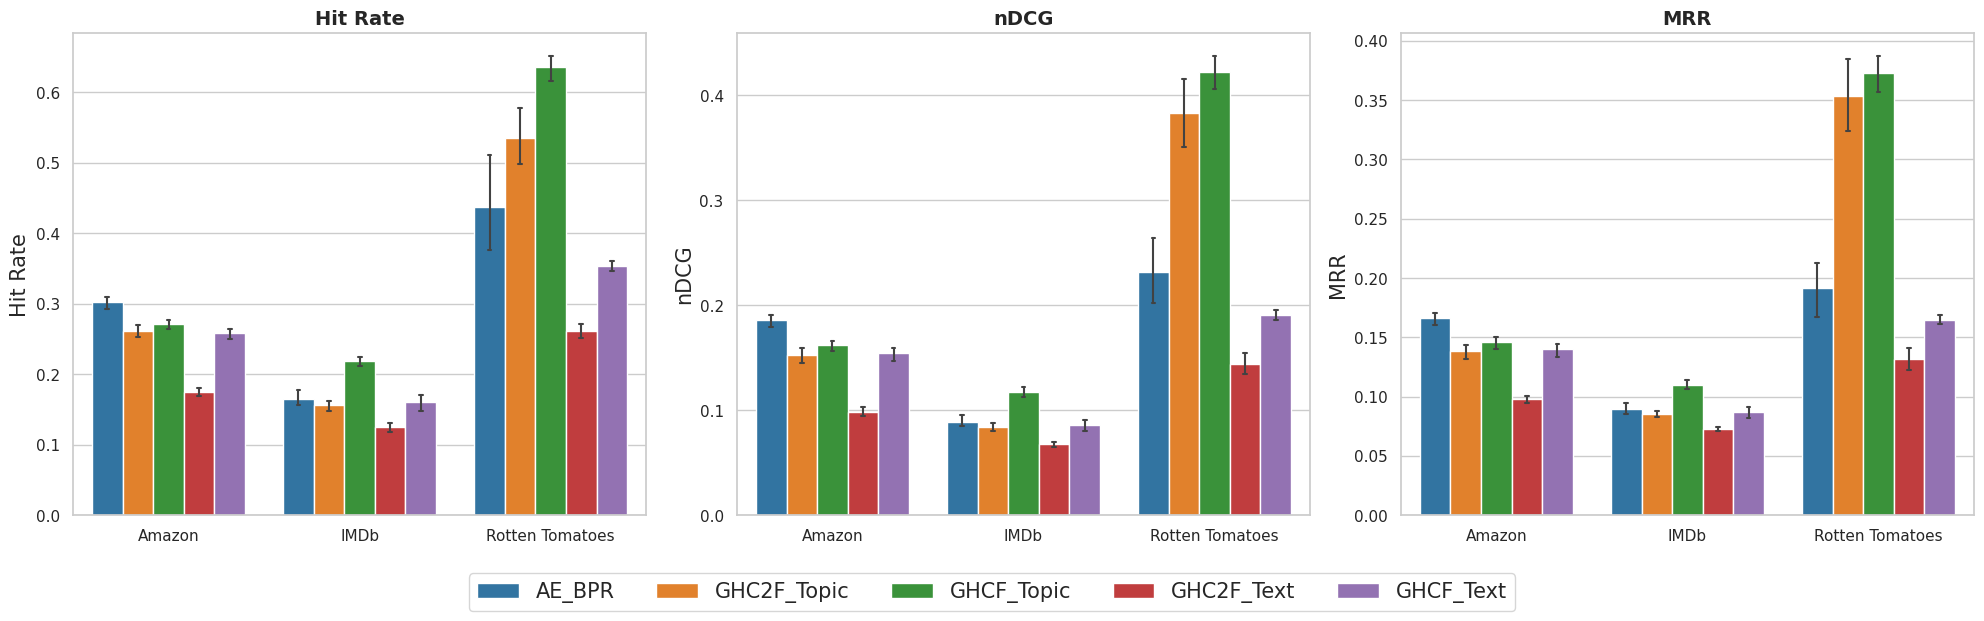

In [23]:
df = pd.read_csv('results_autoencoder.csv')
metrics = ['Hit Rate', 'nDCG', 'MRR']

# Transformar para formato longo (tidy) para facilitar a plotagem
df_melted = df.melt(id_vars=['model', 'dataset', 'fold'],
                    value_vars=metrics,
                    var_name='Metric',
                    value_name='Value')

# 3. Configurações de Estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

# 4. Gerar Gráficos
for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_melted[df_melted['Metric'] == metric],
        x="dataset",
        y="Value",
        hue="model",
        ax=axes[i],
        palette="tab10",
        capsize=.1,
        errwidth=1.5
    )
    axes[i].set_title(f'{metric}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel(metric, fontsize=15)
    axes[i].set_xlabel('', fontsize=50)

    # Remover a legenda interna de cada subplot
    axes[i].get_legend().remove()

# Adicionar uma legenda única para a figura toda
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05),
           ncol=5, fontsize=15)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('comparision_proposal.pdf', dpi=300, bbox_inches='tight')
plt.show()